In [ ]:
from google.colab import files

# Upload a file
uploaded = files.upload()

Saving goodpcb.png to goodpcb.png
Saving template.png to template.png


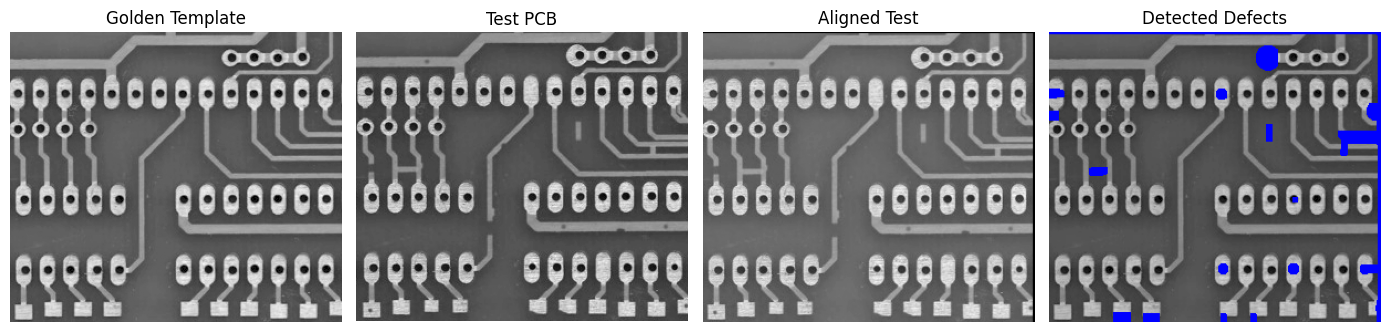

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
ref_path = "goodpcb.png"
test_path = "template.png"
ref = cv2.imread(ref_path, 0)
test = cv2.imread(test_path, 0)
if ref is None:
    raise ValueError(f"Reference image not found: {ref_path}")
if test is None:
    raise ValueError(f"Test PCB image not found: {test_path}")
orb = cv2.ORB_create(5000)
kp1, des1 = orb.detectAndCompute(ref, None)
kp2, des2 = orb.detectAndCompute(test, None)
if des1 is None or des2 is None:
    raise ValueError("Could not detect enough ORB keypoints in one or both images.")
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2)
if len(matches) < 4:
    raise ValueError("Not enough matches detected to compute homography.")
matches = sorted(matches, key=lambda x: x.distance)
src_pts = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1,1,2)
dst_pts = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1,1,2)
H, mask = cv2.findHomography(dst_pts, src_pts, cv2.RANSAC, 5.0)
if H is None:
    raise ValueError("Homography could not be computed. Try clearer images.")
aligned = cv2.warpPerspective(test, H, (ref.shape[1], ref.shape[0]))
diff = cv2.absdiff(ref, aligned)
blur = cv2.GaussianBlur(diff, (7, 7), 0)
_, th = cv2.threshold(blur, 25, 255, cv2.THRESH_BINARY)
kernel = np.ones((5, 5), np.uint8)
clean = cv2.morphologyEx(th, cv2.MORPH_CLOSE, kernel, iterations=2)
clean = cv2.morphologyEx(clean, cv2.MORPH_OPEN, kernel, iterations=1)
overlay = cv2.cvtColor(ref, cv2.COLOR_GRAY2BGR)
overlay[clean > 0] = (0, 0, 255)
plt.figure(figsize=(14, 4))
plt.subplot(1, 4, 1)
plt.imshow(ref, cmap='gray')
plt.title("Golden Template")
plt.axis("off")
plt.subplot(1, 4, 2)
plt.imshow(test, cmap='gray')
plt.title("Test PCB")
plt.axis("off")
plt.subplot(1, 4, 3)
plt.imshow(aligned, cmap='gray')
plt.title("Aligned Test")
plt.axis("off")
plt.subplot(1, 4, 4)
plt.imshow(overlay)
plt.title("Detected Defects")
plt.axis("off")
plt.tight_layout()
plt.show()
